In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
from sklearn.cluster import KMeans
from sklearn import preprocessing
import matplotlib.pyplot as pl
import seaborn as sns

#source: https://stackoverflow.com/questions/33458834/k-means-clustering-in-python
#source: https://stackoverflow.com/questions/57986346/how-to-do-clustering-with-k-means-algorithm-for-an-imported-data-set-with-proper
#genAI used in debugging and where directly cited

Approach: 

For K-Means clustering, the data was divided by the men's and women's leagues, and the goal-keepers were also separated out due to dramatically different playing style for those players. We also explored, carry, shot, and defensive clustering, to see if narrowing features down to these specific traits would be fruitful in our categorization. For the purposes of our analysis, we are focusing on the general clustering of the men, women, and goalkeeprs. To find the appropriate number of clusters, the elbow method was used, by plotting the elbow curve and then determining where the number of clusters levels off.

In [3]:
project_location = Path.cwd()
data_location = Path.cwd().parent/"data"/"additional"
print(project_location)

/Users/oliviawesel/Desktop/soccer-analytics-capstone-template/analysis


In [4]:
# path = project_location/ 'all_k_means.csv'
df = pd.read_parquet(data_location/'all_k_means.parquet')
print(df.head())

   player_id MEN_WOMEN  pct_shot_first_time  pct_shot_follows_dribble  \
0       3043         M             0.223022                       0.0   
1       3570         M             0.347826                       0.0   
2       3959         M             0.310345                       0.0   
3       8621         M             0.400000                       0.0   
4      21261         M             0.555556                       0.0   

   pct_shot_open_goal  pct_shot_dominant_foot  pct_shot_header  \
0            0.000000                0.762590         0.000000   
1            0.000000                0.891304         0.065217   
2            0.068966                0.379310         0.551724   
3            0.000000                0.800000         0.000000   
4            0.000000                0.555556         0.222222   

   pct_shot_goal_scored  pct_shot_taken_saved  shots_per_minute  ...  \
0              0.064748              0.007194          0.032483  ...   
1              0.000

In [5]:
df.isnull().sum()
print(len(df))

9035


In [6]:
df.dropna(inplace=True)
p_ids = df['player_id']
print(len(df))

4840


### Split Men's League and Women's League

In [7]:
df_m = df[df['MEN_WOMEN'] == 'M']
df_m = df.drop(columns=['MEN_WOMEN'])
df_w = df[df['MEN_WOMEN'] == 'W']
df_w = df.drop(columns=['MEN_WOMEN'])

Capture player id's and drop the column for clustering

In [8]:
p_ids_m = df_m['player_id']
p_ids_w = df_w['player_id']
df_m = df_m.drop(columns=['player_id'])
df_w = df_w.drop(columns=['player_id'])

### Men's League

In [9]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df_m)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df_m.index, columns=df_m.columns)
df_numeric_scaled.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_goal_scored,pct_shot_taken_saved,shots_per_minute,goals_over_expected,pct_shot_from_q1_dist,...,pass_attempts_per_minute,percent_cross_success,percent_through_ball_success,percent_pass_through_ball,percent_pass_cross,percent_q1_pass_dist,percent_q2_pass_dist,percent_q3_pass_dist,percent_q4_pass_dist,pass_shot_assist_per_minute
0,0.223022,0.0,0.000000,0.762590,0.000000,0.064748,0.007194,0.135087,0.058686,0.028777,...,0.215080,0.262136,0.407407,0.070654,0.134766,0.307850,0.408224,0.398355,0.350467,0.282148
1,0.347826,0.0,0.000000,0.891304,0.065217,0.000000,0.021739,0.083167,0.037121,0.130435,...,0.251203,0.200000,0.333333,0.012076,0.030190,0.315699,0.448687,0.410351,0.313604,0.064525
2,0.310345,0.0,0.068966,0.379310,0.551724,0.241379,0.034483,0.072305,0.064208,0.655172,...,0.208688,1.000000,0.000000,0.010432,0.001304,0.287817,0.484054,0.507899,0.247898,0.004144
3,0.400000,0.0,0.000000,0.800000,0.000000,0.200000,0.000000,0.056589,0.058598,0.000000,...,0.302432,1.000000,0.000000,0.000000,0.014894,0.510638,0.587801,0.388085,0.109422,0.167071
4,0.555556,0.0,0.000000,0.555556,0.222222,0.000000,0.000000,0.130338,0.045627,0.333333,...,0.068196,0.600000,0.666667,0.165354,0.137795,0.472441,0.455643,0.314961,0.261530,0.217872


In [10]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

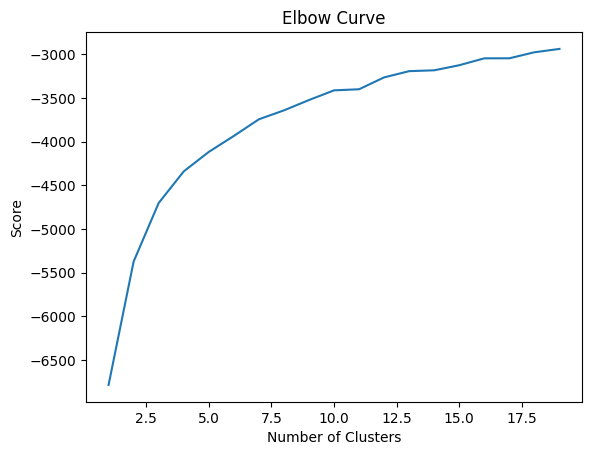

In [11]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [12]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(df_numeric_scaled)
df_m['cluster'] = kmeans.labels_
#collaborated w genAI to add back in player ids
df_m['player_id'] = p_ids_m
df_m.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_goal_scored,pct_shot_taken_saved,shots_per_minute,goals_over_expected,pct_shot_from_q1_dist,...,percent_through_ball_success,percent_pass_through_ball,percent_pass_cross,percent_q1_pass_dist,percent_q2_pass_dist,percent_q3_pass_dist,percent_q4_pass_dist,pass_shot_assist_per_minute,cluster,player_id
0,0.223022,0.0,0.000000,0.762590,0.000000,0.064748,0.007194,0.032483,0.870850,0.028777,...,0.407407,0.010093,0.038505,0.205234,0.218692,0.248972,0.327103,0.029533,0,3043
1,0.347826,0.0,0.000000,0.891304,0.065217,0.000000,0.021739,0.022565,-2.706043,0.130435,...,0.333333,0.001725,0.008626,0.210466,0.240368,0.256469,0.292697,0.006754,0,3570
2,0.310345,0.0,0.068966,0.379310,0.551724,0.241379,0.034483,0.020490,1.786721,0.655172,...,0.000000,0.001490,0.000373,0.191878,0.259314,0.317437,0.231371,0.000434,1,3959
3,0.400000,0.0,0.000000,0.800000,0.000000,0.200000,0.000000,0.017488,0.856207,0.000000,...,0.000000,0.000000,0.004255,0.340426,0.314894,0.242553,0.102128,0.017488,0,8621
4,0.555556,0.0,0.000000,0.555556,0.222222,0.000000,0.000000,0.031576,-1.295278,0.333333,...,0.666667,0.023622,0.039370,0.314961,0.244094,0.196850,0.244094,0.022805,2,21261


In [13]:
#source: https://stackoverflow.com/questions/41066582/python-save-pandas-data-frame-to-parquet-file
df_m.to_parquet('Mens_Clustering.parquet')

In [14]:
len(df_m.columns)

46

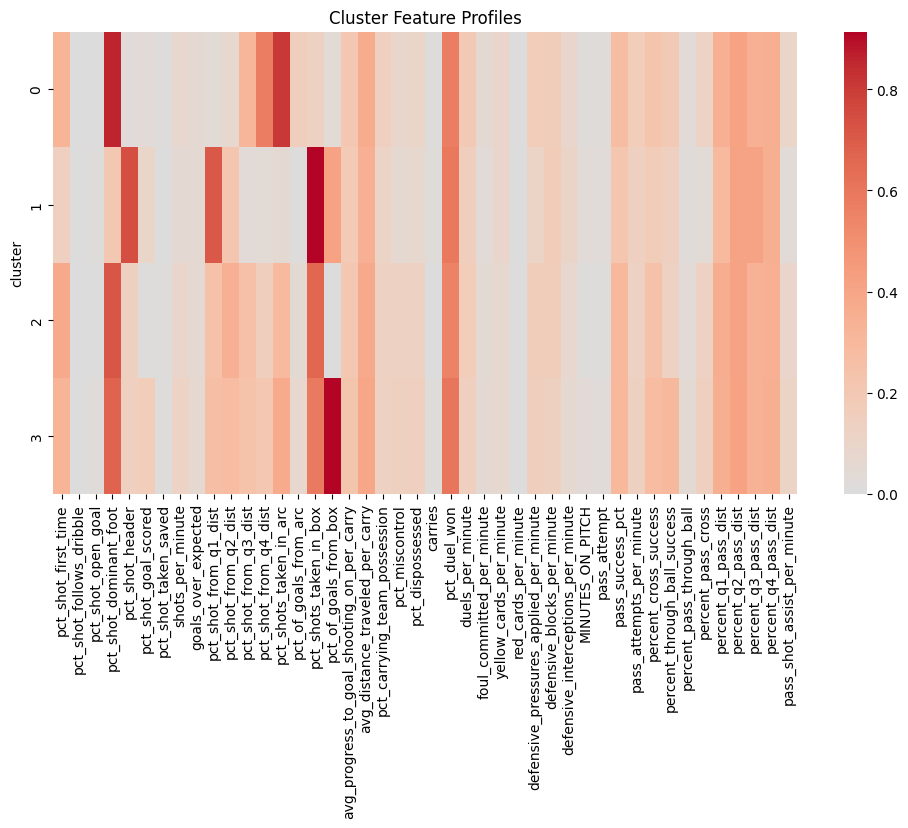

In [15]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df_m['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

For the men's league, there were four primary profiles. 

Cluster 3: Minor strength in pct_shot_first_time, percent_shot_from_q2_dist,  percent_q1_pass_dist, percent_q2_pass_dist, percent_q3_pass_dist, percent_q4_pass_dist

Medium strength in pct_duel_won

High strength in pct_shots_taken_in_box, pct_of_goals_from_box

Cluster 2: This cluster was the least performantive, showing only minor strenght in percent_duals_won, pass_success_pct, and some minor strenght in pass distance from the different quarters

Cluster 1: Minor strength in pct_shot_first_time, pct_shot_from_q3_dist, percent_q1_pass_dist, percent_q2_pass_dist, percent_q3_pass_dist, percent_q4_pass_dist

Medium strength in pct_shot_from_q4_dist, pct_shot_dual_won, 

High strength in pct_shot_dominant_foot, pct_shots_taken_from_in_arc

Cluster 0: Showed minor strength in pct_shot_first_time, pct_shot dominant foot, pct_shot_from_q2_dist, pct_of_goals_from_box, percent_q1_pass_dist, percent_q2_pass_dist, percent_q3_pass_dist, percent_q4_pass_dist
 
Medium strength in percent_shot_header, pct_shot_from_q1_dist, pct_dual_won
 
High strength in pct_shot_taken_from_box, 

### Women's League

In [16]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df_w)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df_w.columns)
df_numeric_scaled.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_goal_scored,pct_shot_taken_saved,shots_per_minute,goals_over_expected,pct_shot_from_q1_dist,...,pass_attempts_per_minute,percent_cross_success,percent_through_ball_success,percent_pass_through_ball,percent_pass_cross,percent_q1_pass_dist,percent_q2_pass_dist,percent_q3_pass_dist,percent_q4_pass_dist,pass_shot_assist_per_minute
0,0.223022,0.0,0.000000,0.762590,0.000000,0.064748,0.007194,0.135087,0.058686,0.028777,...,0.215080,0.262136,0.407407,0.070654,0.134766,0.307850,0.408224,0.398355,0.350467,0.282148
1,0.347826,0.0,0.000000,0.891304,0.065217,0.000000,0.021739,0.083167,0.037121,0.130435,...,0.251203,0.200000,0.333333,0.012076,0.030190,0.315699,0.448687,0.410351,0.313604,0.064525
2,0.310345,0.0,0.068966,0.379310,0.551724,0.241379,0.034483,0.072305,0.064208,0.655172,...,0.208688,1.000000,0.000000,0.010432,0.001304,0.287817,0.484054,0.507899,0.247898,0.004144
3,0.400000,0.0,0.000000,0.800000,0.000000,0.200000,0.000000,0.056589,0.058598,0.000000,...,0.302432,1.000000,0.000000,0.000000,0.014894,0.510638,0.587801,0.388085,0.109422,0.167071
4,0.555556,0.0,0.000000,0.555556,0.222222,0.000000,0.000000,0.130338,0.045627,0.333333,...,0.068196,0.600000,0.666667,0.165354,0.137795,0.472441,0.455643,0.314961,0.261530,0.217872


In [17]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

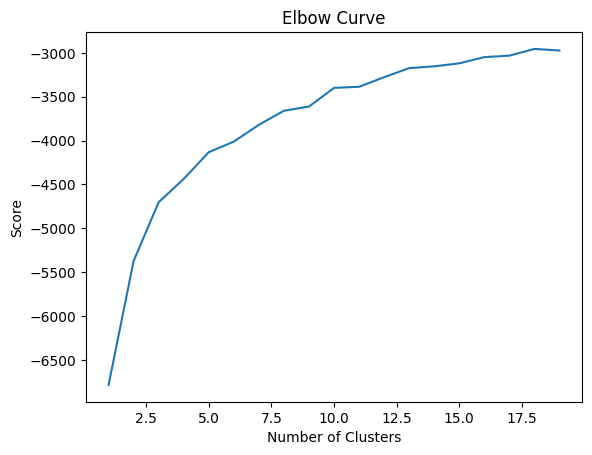

In [18]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [19]:
kmeans = KMeans(n_clusters=6)
kmeans.fit(df_numeric_scaled)
df_w['cluster'] = kmeans.labels_
#collaborated w genAI to add back in player ids
df_w['player_id'] = p_ids_w
df_w.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_goal_scored,pct_shot_taken_saved,shots_per_minute,goals_over_expected,pct_shot_from_q1_dist,...,percent_through_ball_success,percent_pass_through_ball,percent_pass_cross,percent_q1_pass_dist,percent_q2_pass_dist,percent_q3_pass_dist,percent_q4_pass_dist,pass_shot_assist_per_minute,cluster,player_id
0,0.223022,0.0,0.000000,0.762590,0.000000,0.064748,0.007194,0.032483,0.870850,0.028777,...,0.407407,0.010093,0.038505,0.205234,0.218692,0.248972,0.327103,0.029533,5,3043
1,0.347826,0.0,0.000000,0.891304,0.065217,0.000000,0.021739,0.022565,-2.706043,0.130435,...,0.333333,0.001725,0.008626,0.210466,0.240368,0.256469,0.292697,0.006754,0,3570
2,0.310345,0.0,0.068966,0.379310,0.551724,0.241379,0.034483,0.020490,1.786721,0.655172,...,0.000000,0.001490,0.000373,0.191878,0.259314,0.317437,0.231371,0.000434,3,3959
3,0.400000,0.0,0.000000,0.800000,0.000000,0.200000,0.000000,0.017488,0.856207,0.000000,...,0.000000,0.000000,0.004255,0.340426,0.314894,0.242553,0.102128,0.017488,5,8621
4,0.555556,0.0,0.000000,0.555556,0.222222,0.000000,0.000000,0.031576,-1.295278,0.333333,...,0.666667,0.023622,0.039370,0.314961,0.244094,0.196850,0.244094,0.022805,4,21261


In [20]:
len(df_w.columns)

46

In [21]:
#source: https://stackoverflow.com/questions/41066582/python-save-pandas-data-frame-to-parquet-file
df_w.to_parquet('Womens_Clustering.parquet')

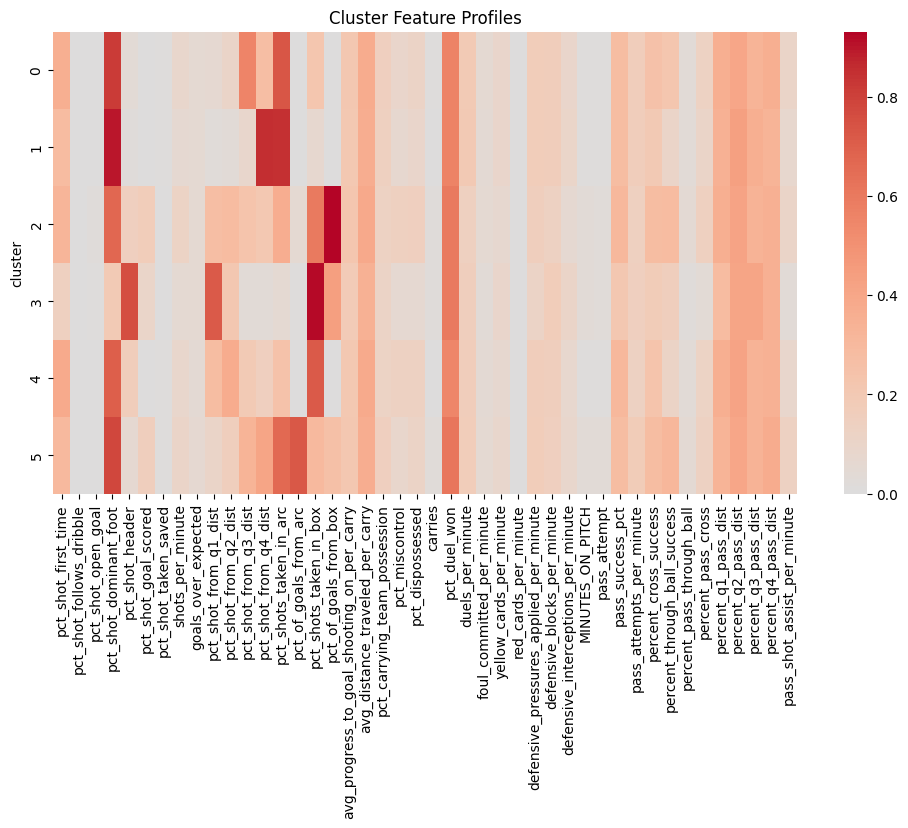

In [22]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df_w['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

For the women's league there were four clusters, 
Cluster 3: Minor strenght in pct_duel_won, and percent_q1_pass_dist, percent_q2_pass_dist, percent_q3_pass_dist, percent_q4_pass_dist

Cluster 2:  Minor strength in pct_shot_first_time, pct_shot_header, pct_shot_from_q1_dist, pct_shot_from_q2_dist, percent_q1_pass_dist, percent_q2_pass_dist, percent_q3_pass_dist, percent_q4_pass_dist

Medium strength in pct_shot_dominant_foot, pct_of_goals_from_box, pct_duel won

High strength in pct_shots_taken_in_box

Cluster 1: Minor strength in pct_duel_won, pass_success_pct,

High strength in percent_q4_pass_dist


Cluster 0: Minor strength in pct_shot_first_time, pct_shot_from_q3_dist, pct_shot_from_q4_dist, percent_q1_pass_dist, percent_q2_pass_dist, percent_q3_pass_dist, percent_q4_pass_dist

Medium strength in pct_shots_taken_from_arc, pct_duel_won

High strength in pct_shot_dominant_foot

## Carry K-Means

In [23]:
df = pd.read_parquet(data_location/'carry_k_means.parquet')
print(df.head())

   player_id  avg_progress_to_goal_shooting_on_per_carry  \
0      11746                                    1.014954   
1       3477                                    2.682264   
2       3874                                    1.544288   
3       3629                                    3.896256   
4      10499                                    3.279143   

   avg_distance_traveled_per_carry  pct_carrying_team_possession  \
0                         4.399259                      0.042749   
1                         7.050323                      0.026689   
2                         5.080311                      0.044520   
3                         8.452967                      0.061305   
4                         7.355203                      0.038172   

   pct_miscontrol  pct_dispossessed  carries  
0        0.021505          0.053763     93.0  
1        0.106855          0.087702    992.0  
2        0.018397          0.029566   1522.0  
3        0.074249          0.058928   1697

In [24]:
df.isnull().sum()
print(len(df))

8986


In [25]:
df.dropna(inplace=True)
print(len(df))

5698


In [26]:
df = df.drop(columns=['player_id'])

In [27]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df.columns)
df_numeric_scaled.head()

,avg_progress_to_goal_shooting_on_per_carry,avg_distance_traveled_per_carry,pct_carrying_team_possession,pct_miscontrol,pct_dispossessed,carries
0,0.092036,0.237918,0.126973,0.043011,0.143369,0.002285
1,0.243227,0.462079,0.075298,0.213710,0.233871,0.025633
2,0.140035,0.295504,0.132675,0.036794,0.078844,0.039397
3,0.353311,0.580680,0.186683,0.148497,0.157140,0.043942
4,0.297352,0.487859,0.112247,0.114695,0.114695,0.007116


In [28]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

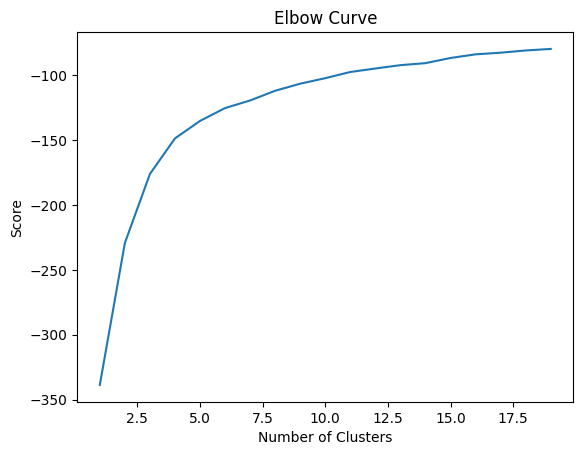

In [29]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [30]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
df['player_id'] = p_ids
df.head()

,avg_progress_to_goal_shooting_on_per_carry,avg_distance_traveled_per_carry,pct_carrying_team_possession,pct_miscontrol,pct_dispossessed,carries,cluster,player_id
0,1.014954,4.399259,0.042749,0.021505,0.053763,93.0,2,3043.0
1,2.682264,7.050323,0.026689,0.106855,0.087702,992.0,1,3570.0
2,1.544288,5.080311,0.044520,0.018397,0.029566,1522.0,2,3959.0
3,3.896256,8.452967,0.061305,0.074249,0.058928,1697.0,3,8621.0
4,3.279143,7.355203,0.038172,0.057348,0.043011,279.0,0,21261.0


In [31]:
len(df.columns)

8

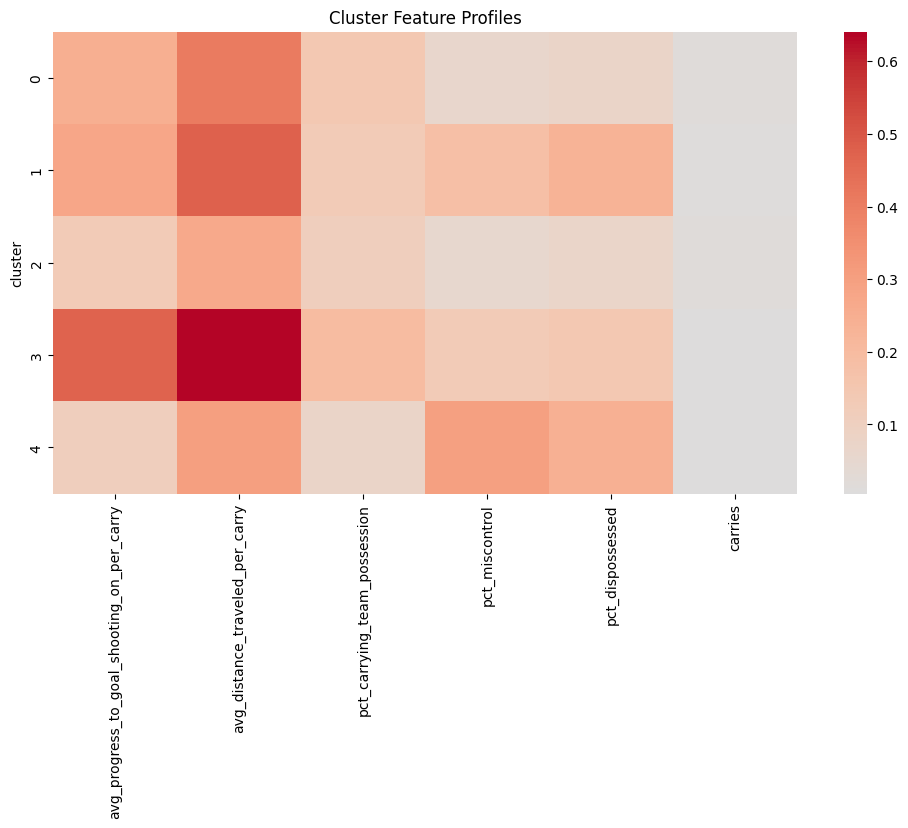

In [32]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

## Defense K-Means

In [33]:
df = pd.read_parquet(data_location/'defense_k_means.parquet')
print(df.head())

   player_id  pct_duel_won  duels_per_minute  foul_committed_per_minute  \
0      18149      0.673077          0.034443                   0.000000   
1      18253      0.571429          0.018007                   0.000857   
2       3321      0.678161          0.024297                   0.000000   
3      15648      0.644068          0.029157                   0.000494   
4      10188      0.798165          0.021724                   0.000399   

   yellow_cards_per_minute  red_cards_per_minute  \
0                 0.001987                   0.0   
1                 0.001715                   0.0   
2                 0.000279                   0.0   
3                 0.000988                   0.0   
4                 0.000399                   0.0   

   pressures_applied_per_minute  blocks_per_minute  interceptions_per_minute  
0                      0.162612           0.019540                  0.002981  
1                      0.265821           0.016292                  0.000857  

In [34]:
df.isnull().sum()
print(len(df))

8702


In [35]:
df.dropna(inplace=True)
print(len(df))

7393


In [36]:
df = df.drop(columns=['player_id'])

In [37]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df.columns)
df_numeric_scaled.head()

,pct_duel_won,duels_per_minute,foul_committed_per_minute,yellow_cards_per_minute,red_cards_per_minute,pressures_applied_per_minute,blocks_per_minute,interceptions_per_minute
0,0.673077,0.160908,0.000000,0.061667,0.0,0.147509,0.187909,0.048759
1,0.571429,0.084124,0.016024,0.053221,0.0,0.241131,0.156677,0.014027
2,0.678161,0.113506,0.000000,0.008667,0.0,0.110707,0.182626,0.095937
3,0.644068,0.136214,0.009235,0.030673,0.0,0.143005,0.123565,0.064673
4,0.798165,0.101489,0.007449,0.012370,0.0,0.123483,0.126500,0.048905


In [38]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

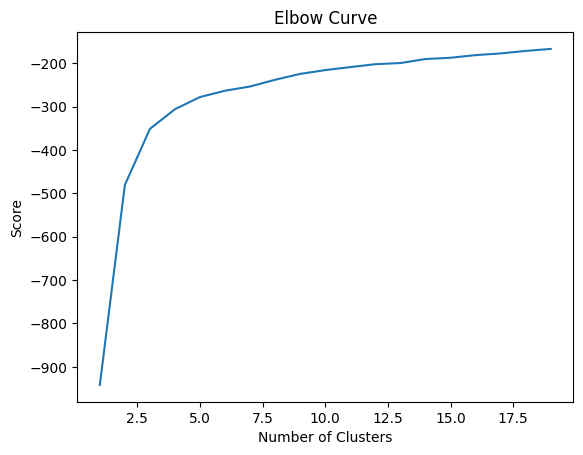

In [39]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [40]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
df['player_id'] = p_ids
df.head()

,pct_duel_won,duels_per_minute,foul_committed_per_minute,yellow_cards_per_minute,red_cards_per_minute,pressures_applied_per_minute,blocks_per_minute,interceptions_per_minute,cluster,player_id
0,0.673077,0.034443,0.000000,0.001987,0.0,0.162612,0.019540,0.002981,1,3043.0
1,0.571429,0.018007,0.000857,0.001715,0.0,0.265821,0.016292,0.000857,1,3570.0
2,0.678161,0.024297,0.000000,0.000279,0.0,0.122042,0.018991,0.005865,1,3959.0
3,0.644068,0.029157,0.000494,0.000988,0.0,0.157648,0.012849,0.003954,1,8621.0
4,0.798165,0.021724,0.000399,0.000399,0.0,0.136126,0.013154,0.002990,2,21261.0


In [41]:
#source: https://stackoverflow.com/questions/41066582/python-save-pandas-data-frame-to-parquet-file
df.to_parquet('Defense_Clustering.parquet')

In [42]:
len(df.columns)

10

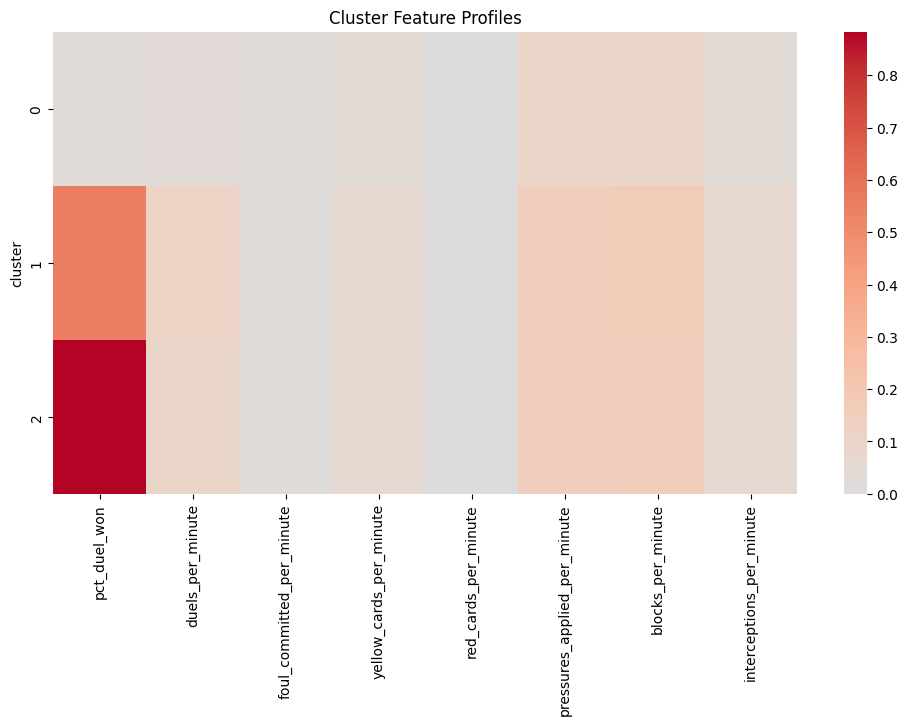

In [43]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

## Goal Keeper K-Means

In [44]:
df = pd.read_parquet(data_location/'gk_k_means.parquet')
print(df.head())

   gk_player_id  gk_shot_save_pct  gk_penalty_save_pct  pct_q1_shot_xg  \
0          8240          0.876712                  0.0        0.109589   
1          6706          0.703704                  0.0        0.055556   
2          4981          0.722222                  0.0        0.041667   
3          6610          0.733624                  0.0        0.139738   
4          6730          0.598592                  0.0        0.098592   

   pct_q2_shot_xg  pct_q3_shot_xg  pct_q4_shot_xg  gk_collected_per_minute  \
0        0.041096        0.164384        0.506849                 0.013564   
1        0.129630        0.203704        0.259259                 0.012649   
2        0.111111        0.111111        0.361111                 0.010129   
3        0.139738        0.109170        0.283843                 0.013721   
4        0.070423        0.140845        0.246479                 0.010617   

   gk_keeper_sweeper_per_minute  gk_smother_per_minute  gk_punch_per_minute  \
0      

In [45]:
df.isnull().sum()
print(len(df))

501


In [46]:
df.dropna(inplace=True)
print(len(df))
gk_p_ids = df['gk_player_id']

499


### Split Men's League and Women's League

In [47]:
df_m_gk = df[df['MEN_WOMEN'] == 'M']
df_m_gk = df.drop(columns=['MEN_WOMEN'])
df_w_gk = df[df['MEN_WOMEN'] == 'W']
df_w_gk = df.drop(columns=['MEN_WOMEN'])

Capture player id's and drop the column for clustering

In [48]:
p_ids_m_gk = df_m_gk['gk_player_id']
p_ids_w_gk = df_w_gk['gk_player_id']
df_m_gk = df_m_gk.drop(columns=['gk_player_id'])
df_w_gk = df_w_gk.drop(columns=['gk_player_id'])

Men's League

In [49]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df_m_gk)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df_m_gk.index, columns=df_m_gk.columns)
df_numeric_scaled.head()

,gk_shot_save_pct,gk_penalty_save_pct,pct_q1_shot_xg,pct_q2_shot_xg,pct_q3_shot_xg,pct_q4_shot_xg,gk_collected_per_minute,gk_keeper_sweeper_per_minute,gk_smother_per_minute,gk_punch_per_minute,gk_shot_faced_per_minute,gk_penalty_faced_per_minute,pct_shot_from_gk_right,pct_shot_from_gk_left,pct_shot_from_gk_unk
0,0.547945,0.0,0.219178,0.082192,0.328767,0.506849,0.261478,0.270040,0.055587,0.070325,0.225375,0.0,0.342466,0.315068,0.342466
1,0.439815,0.0,0.111111,0.259259,0.407407,0.259259,0.243854,0.255542,0.000000,0.125704,0.317629,0.0,0.388889,0.500000,0.111111
2,0.451389,0.0,0.083333,0.222222,0.222222,0.361111,0.195262,0.333457,0.106081,0.402622,0.477951,0.0,0.444444,0.375000,0.180556
3,0.458515,0.0,0.279476,0.279476,0.218341,0.283843,0.264512,0.362614,0.048805,0.246980,0.333342,0.0,0.388646,0.427948,0.183406
4,0.374120,0.0,0.197183,0.140845,0.281690,0.246479,0.204677,0.261115,0.043512,0.187164,0.375002,0.0,0.380282,0.408451,0.211268


In [50]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

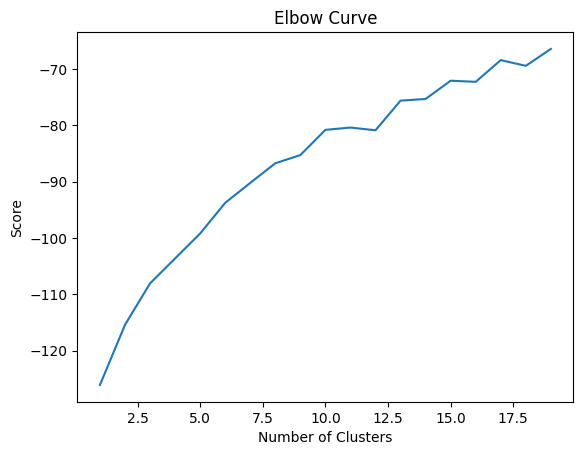

In [51]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [52]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
#collaborated w genAI to add back in player ids
df['gk_player_id'] = p_ids_m_gk
df.head()

,gk_player_id,gk_shot_save_pct,gk_penalty_save_pct,pct_q1_shot_xg,pct_q2_shot_xg,pct_q3_shot_xg,pct_q4_shot_xg,gk_collected_per_minute,gk_keeper_sweeper_per_minute,gk_smother_per_minute,gk_punch_per_minute,gk_shot_faced_per_minute,gk_penalty_faced_per_minute,pct_shot_from_gk_right,pct_shot_from_gk_left,pct_shot_from_gk_unk,MEN_WOMEN,cluster
0,8240,0.876712,0.0,0.109589,0.041096,0.164384,0.506849,0.013564,0.010025,0.000590,0.002949,0.043050,0.0,0.342466,0.315068,0.342466,M,0
1,6706,0.703704,0.0,0.055556,0.129630,0.203704,0.259259,0.012649,0.009487,0.000000,0.005271,0.056923,0.0,0.388889,0.500000,0.111111,M,1
2,4981,0.722222,0.0,0.041667,0.111111,0.111111,0.361111,0.010129,0.012380,0.001125,0.016881,0.081031,0.0,0.444444,0.375000,0.180556,W,1
3,6610,0.733624,0.0,0.139738,0.139738,0.109170,0.283843,0.013721,0.013462,0.000518,0.010356,0.059285,0.0,0.388646,0.427948,0.183406,M,2
4,6730,0.598592,0.0,0.098592,0.070423,0.140845,0.246479,0.010617,0.009694,0.000462,0.007848,0.065550,0.0,0.380282,0.408451,0.211268,M,2


In [53]:
df.to_parquet('Goal_Keeper_Clustering_Men.parquet')

In [54]:
len(df.columns)

18

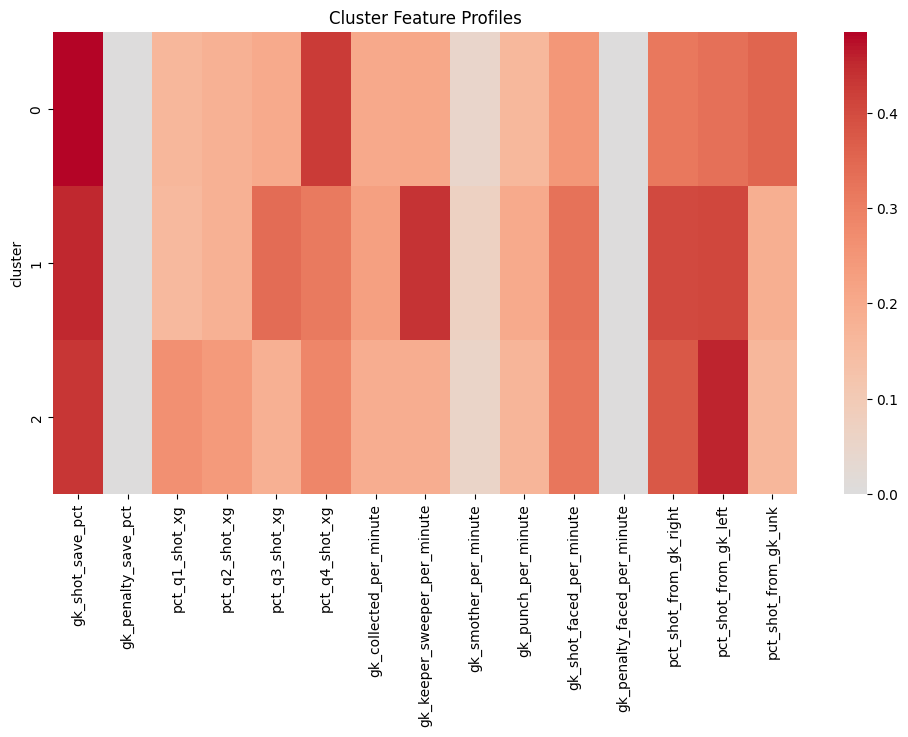

In [55]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

For the mens goalkeeprs there were three clusters

Cluster 0: showed the highest gk_shot_save_pct, the most strenght in pct_q4_shot_xg, and some medium/low strength in pct_shot_from_gk_right, pct_shot_from_gk_left, pct_shot_from_gk_unk

Cluster 1: showed strength in gk_shot_save_pct, but a notch below cluster 0, high strenght in gk_keeper_sweeper_per_minute, and medium strenght in pct_shot_from_gk_right, pct_shot_from_gk_left, and gk_shot_faced_per_minute was the highest of hte clusters.

Cluster 2: showed strength in gk_shot_save_pct, but was the lowest of the clusters, slightly lower gk_shot_faced_per_minute than cluster 1, mediums strenght in pct_shot_from_gk_right and high strength in pct_shot_from_gk_left

Women's League

In [56]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df_w_gk)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df_w_gk.index, columns=df_w_gk.columns)
df_numeric_scaled.head()

,gk_shot_save_pct,gk_penalty_save_pct,pct_q1_shot_xg,pct_q2_shot_xg,pct_q3_shot_xg,pct_q4_shot_xg,gk_collected_per_minute,gk_keeper_sweeper_per_minute,gk_smother_per_minute,gk_punch_per_minute,gk_shot_faced_per_minute,gk_penalty_faced_per_minute,pct_shot_from_gk_right,pct_shot_from_gk_left,pct_shot_from_gk_unk
0,0.547945,0.0,0.219178,0.082192,0.328767,0.506849,0.261478,0.270040,0.055587,0.070325,0.225375,0.0,0.342466,0.315068,0.342466
1,0.439815,0.0,0.111111,0.259259,0.407407,0.259259,0.243854,0.255542,0.000000,0.125704,0.317629,0.0,0.388889,0.500000,0.111111
2,0.451389,0.0,0.083333,0.222222,0.222222,0.361111,0.195262,0.333457,0.106081,0.402622,0.477951,0.0,0.444444,0.375000,0.180556
3,0.458515,0.0,0.279476,0.279476,0.218341,0.283843,0.264512,0.362614,0.048805,0.246980,0.333342,0.0,0.388646,0.427948,0.183406
4,0.374120,0.0,0.197183,0.140845,0.281690,0.246479,0.204677,0.261115,0.043512,0.187164,0.375002,0.0,0.380282,0.408451,0.211268


In [57]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

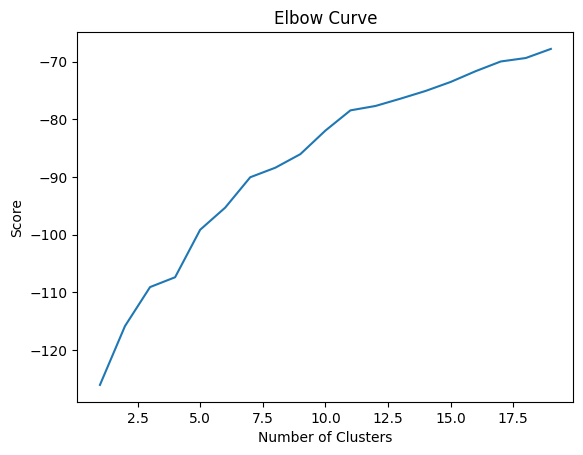

In [58]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [59]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(df_numeric_scaled)
df_w_gk['cluster'] = kmeans.labels_
#collaborated w genAI to add back in player ids
df_w_gk['gk_player_id'] = p_ids_w_gk
df_w_gk.head()

,gk_shot_save_pct,gk_penalty_save_pct,pct_q1_shot_xg,pct_q2_shot_xg,pct_q3_shot_xg,pct_q4_shot_xg,gk_collected_per_minute,gk_keeper_sweeper_per_minute,gk_smother_per_minute,gk_punch_per_minute,gk_shot_faced_per_minute,gk_penalty_faced_per_minute,pct_shot_from_gk_right,pct_shot_from_gk_left,pct_shot_from_gk_unk,cluster,gk_player_id
0,0.876712,0.0,0.109589,0.041096,0.164384,0.506849,0.013564,0.010025,0.000590,0.002949,0.043050,0.0,0.342466,0.315068,0.342466,3,8240
1,0.703704,0.0,0.055556,0.129630,0.203704,0.259259,0.012649,0.009487,0.000000,0.005271,0.056923,0.0,0.388889,0.500000,0.111111,4,6706
2,0.722222,0.0,0.041667,0.111111,0.111111,0.361111,0.010129,0.012380,0.001125,0.016881,0.081031,0.0,0.444444,0.375000,0.180556,4,4981
3,0.733624,0.0,0.139738,0.139738,0.109170,0.283843,0.013721,0.013462,0.000518,0.010356,0.059285,0.0,0.388646,0.427948,0.183406,4,6610
4,0.598592,0.0,0.098592,0.070423,0.140845,0.246479,0.010617,0.009694,0.000462,0.007848,0.065550,0.0,0.380282,0.408451,0.211268,4,6730


In [60]:
len(df_w_gk.columns)

17

In [61]:
#source: https://stackoverflow.com/questions/41066582/python-save-pandas-data-frame-to-parquet-file
df_w_gk.to_parquet('Goal_Keeper_Clustering_Women.parquet')

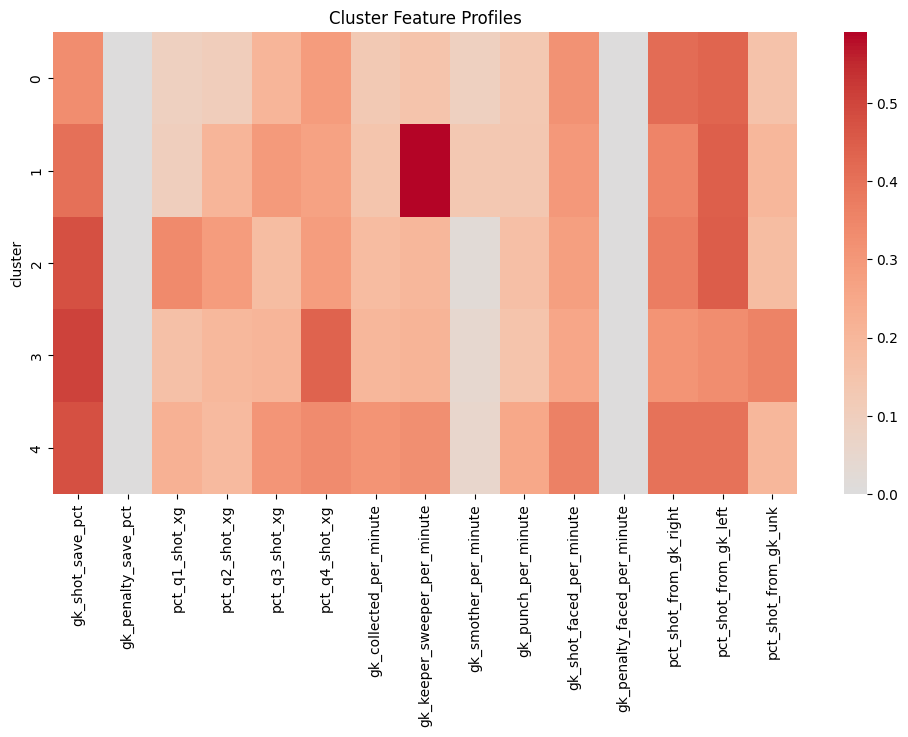

In [62]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df_w_gk['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

For the women's leage goal keeper clusters, it was more difficult to select the number of clusters from the elbow chart. The most consistent notable difference between the clusters is the gk_shot_save_pct, with a notable change in cluster 1 with a high strength in gk_keeper_seeper_per_minute, and cluster 3, which had the highest gk_shot_save_pct, also had the highest pct_q4_shot_xg, the lowest pct_shot_from_gk_right and pct_shot_from_gk_left and the highest pct_shot_from_gk_unk.

## Pass K-Means

In [63]:
df = pd.read_parquet(data_location/'pass_k_means.parquet')
print(df.head())

   player_id  MINUTES_ON_PITCH  pass_attempt  pass_success_pct  \
0       8517       3184.333333        1307.0          0.296098   
1      25863       1515.550000         866.0          0.176674   
2      19634        226.433333          91.0          0.065934   
3       5506      16429.483333       12222.0          0.069383   
4       3385       8347.366667        3814.0          0.215522   

   pass_attempts_per_minute  percent_cross_success  \
0                  0.410447               0.000000   
1                  0.571410               0.212121   
2                  0.401884               0.000000   
3                  0.743907               0.142857   
4                  0.456911               0.387283   

   percent_through_ball_success  percent_through_ball  percent_cross  \
0                      0.000000              0.000000       0.000000   
1                      0.250000              0.004619       0.038106   
2                      0.000000              0.010989       0.

In [64]:
df.isnull().sum()
print(len(df))

8981


In [65]:
df.dropna(inplace=True)
print(len(df))

7668


In [66]:
df = df.drop(columns=['player_id'])

In [67]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df.columns)
df_numeric_scaled.head()

,MINUTES_ON_PITCH,pass_attempt,pass_success_pct,pass_attempts_per_minute,percent_cross_success,percent_through_ball_success,percent_through_ball,percent_cross,percent_q1,percent_q2,percent_q3,percent_q4,pass_shot_assist_per_minute
0,0.060360,0.038036,0.333110,0.154578,0.000000,0.000000,0.000000,0.000000,0.233359,0.463963,0.276533,0.219348,0.000000
1,0.027912,0.025192,0.198759,0.216554,0.212121,0.250000,0.023095,0.083834,0.177829,0.454503,0.229847,0.328666,0.043099
2,0.002846,0.002621,0.074176,0.151281,0.000000,0.000000,0.054945,0.000000,0.153846,0.404396,0.310832,0.305975,0.000000
3,0.317899,0.355924,0.078056,0.282971,0.142857,0.469388,0.020046,0.001260,0.132793,0.337359,0.304291,0.377332,0.018553
4,0.160750,0.111050,0.242462,0.172468,0.387283,0.508475,0.077347,0.099790,0.235186,0.376298,0.252978,0.297154,0.113030


In [68]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

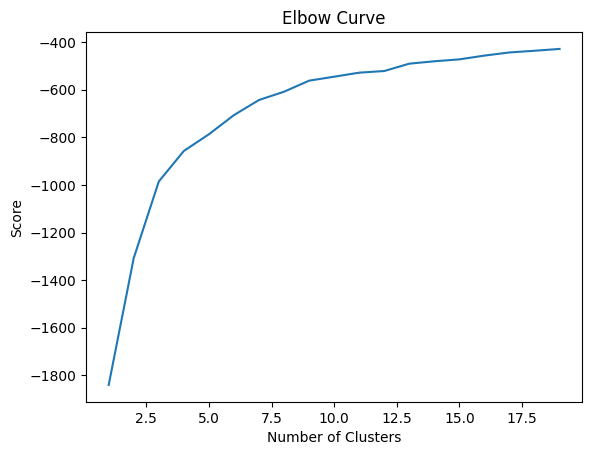

In [69]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [70]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
#collaborated w genAI to add back in player ids
df['player_id'] = p_ids
df.head()

,MINUTES_ON_PITCH,pass_attempt,pass_success_pct,pass_attempts_per_minute,percent_cross_success,percent_through_ball_success,percent_through_ball,percent_cross,percent_q1,percent_q2,percent_q3,percent_q4,pass_shot_assist_per_minute,cluster,player_id
0,3184.333333,1307.0,0.296098,0.410447,0.000000,0.000000,0.000000,0.000000,0.233359,0.289977,0.263963,0.212701,0.000000,0,3043.0
1,1515.550000,866.0,0.176674,0.571410,0.212121,0.250000,0.004619,0.038106,0.177829,0.284065,0.219400,0.318707,0.005938,0,3570.0
2,226.433333,91.0,0.065934,0.401884,0.000000,0.000000,0.010989,0.000000,0.153846,0.252747,0.296703,0.296703,0.000000,3,3959.0
3,16429.483333,12222.0,0.069383,0.743907,0.142857,0.469388,0.004009,0.000573,0.132793,0.210849,0.290460,0.365898,0.002556,1,8621.0
4,8347.366667,3814.0,0.215522,0.456911,0.387283,0.508475,0.015469,0.045359,0.235186,0.235186,0.241479,0.288149,0.015574,1,21261.0


In [71]:
len(df.columns)

15

In [72]:
#source: https://stackoverflow.com/questions/41066582/python-save-pandas-data-frame-to-parquet-file
df_m.to_parquet('Pass_Clustering.parquet')

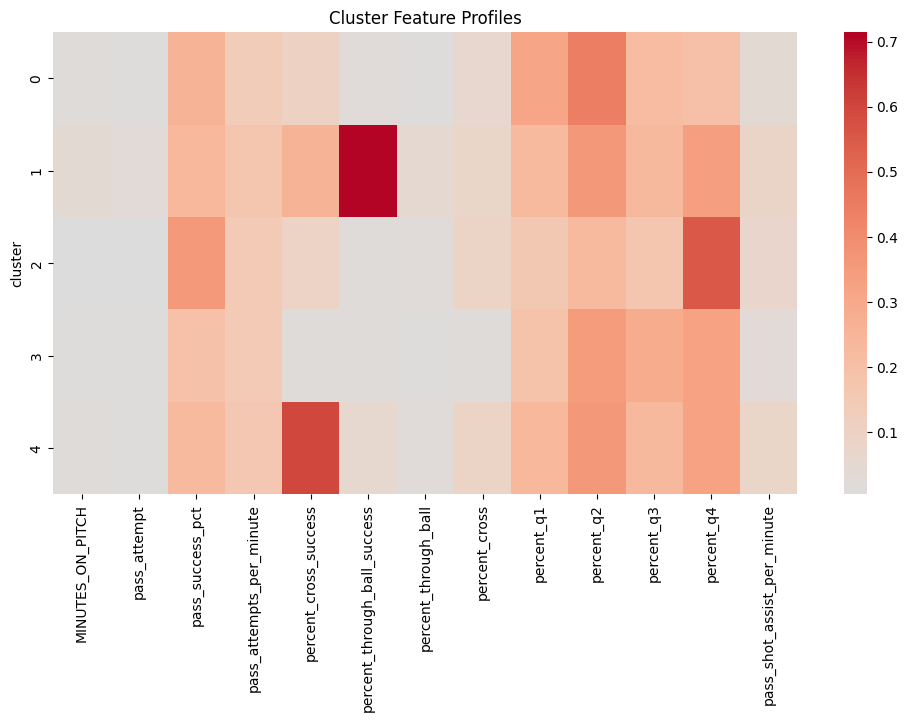

In [73]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

## Shot K-Means

In [74]:
df = pd.read_parquet(data_location/'shot_k_means.parquet')
print(df.head())

   player_id  pct_shot_first_time  pct_shot_follows_dribble  \
0      26101             0.200000                       0.0   
1      40486             0.428571                       0.0   
2      19757             0.252427                       0.0   
3       3629             0.273504                       0.0   
4       3616             0.210526                       0.0   

   pct_shot_open_goal  pct_shot_dominant_foot  pct_shot_header  \
0            0.000000                0.800000         0.000000   
1            0.035714                0.607143         0.178571   
2            0.009709                0.864078         0.019417   
3            0.025641                0.529915         0.059829   
4            0.000000                0.736842         0.052632   

   pct_shot_into_goal  pct_shot_saved  shots_per_minute  goals_over_expected  \
0            0.000000        0.000000          0.054536            -0.299891   
1            0.035714        0.000000          0.024415         

In [75]:
df.isnull().sum()
print(len(df))

6144


In [76]:
df.dropna(inplace=True)
print(len(df))

5477


In [77]:
df = df.drop(columns=['player_id'])

In [78]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df.columns)
df_numeric_scaled.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_into_goal,pct_shot_saved,shots_per_minute,goals_over_expected,pct_shot_q1,pct_shot_q2,pct_shot_q3,pct_shot_q4,pct_shots_taken_in_arc,pct_of_goals_from_arc,pct_shots_taken_in_box,pct_of_goals_from_box
0,0.200000,0.0,0.000000,0.800000,0.000000,0.000000,0.000000,0.251069,0.051628,0.200000,0.000000,0.800000,0.000000,0.400000,0.000000,0.600000,0.000000
1,0.428571,0.0,0.035714,0.607143,0.178571,0.035714,0.000000,0.093512,0.039793,0.142857,0.285714,0.285714,0.285714,0.428571,0.000000,0.553571,1.000000
2,0.252427,0.0,0.009709,0.864078,0.019417,0.067961,0.009709,0.089699,0.060456,0.058252,0.135922,0.330097,0.475728,0.747573,0.714286,0.252427,0.285714
3,0.273504,0.0,0.025641,0.529915,0.059829,0.136752,0.000000,0.160607,0.049096,0.213675,0.418803,0.264957,0.102564,0.333333,0.125000,0.658120,0.875000
4,0.210526,0.0,0.000000,0.736842,0.052632,0.315789,0.000000,0.093796,0.065081,0.315789,0.473684,0.157895,0.052632,0.210526,0.000000,0.736842,1.000000


In [79]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

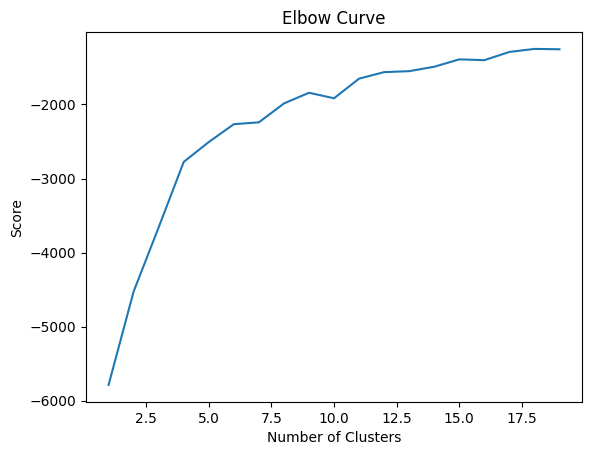

In [80]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [81]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
#collaborated w genAI to add back in player ids
df['player_id'] = p_ids
df.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_into_goal,pct_shot_saved,shots_per_minute,goals_over_expected,pct_shot_q1,pct_shot_q2,pct_shot_q3,pct_shot_q4,pct_shots_taken_in_arc,pct_of_goals_from_arc,pct_shots_taken_in_box,pct_of_goals_from_box,cluster,player_id
0,0.200000,0.0,0.000000,0.800000,0.000000,0.000000,0.000000,0.054536,-0.299891,0.200000,0.000000,0.800000,0.000000,0.400000,0.000000,0.600000,0.000000,1,3043.0
1,0.428571,0.0,0.035714,0.607143,0.178571,0.035714,0.000000,0.024415,-2.262913,0.142857,0.285714,0.285714,0.285714,0.428571,0.000000,0.553571,1.000000,2,3570.0
2,0.252427,0.0,0.009709,0.864078,0.019417,0.067961,0.009709,0.023686,1.164438,0.058252,0.135922,0.330097,0.475728,0.747573,0.714286,0.252427,0.285714,1,3959.0
3,0.273504,0.0,0.025641,0.529915,0.059829,0.136752,0.000000,0.037241,-0.719881,0.213675,0.418803,0.264957,0.102564,0.333333,0.125000,0.658120,0.875000,2,8621.0
4,0.210526,0.0,0.000000,0.736842,0.052632,0.315789,0.000000,0.024469,1.931559,0.315789,0.473684,0.157895,0.052632,0.210526,0.000000,0.736842,1.000000,2,21261.0


In [82]:
#source: https://stackoverflow.com/questions/41066582/python-save-pandas-data-frame-to-parquet-file
df_m.to_parquet('Shot_Clustering.parquet')

In [83]:
len(df.columns)

19

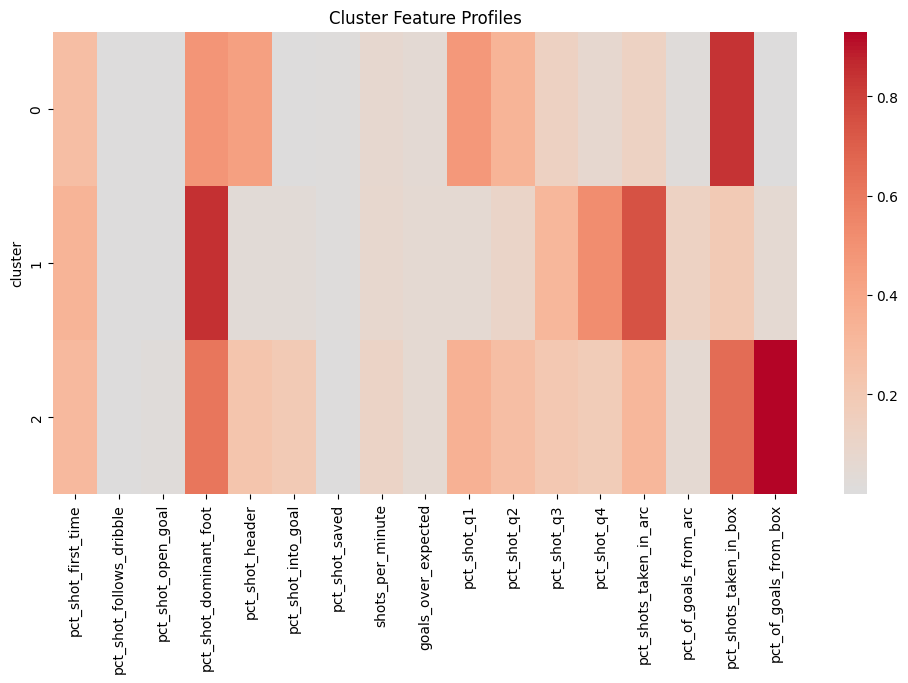

In [84]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()